# 93b — Review nodal source-position estimates

This notebook audits the outputs of `93_estimate_nodal_source_positions_SAFE.ipynb`
before inferred nodal-only shot groups or stacks are created.

It is deliberately **read-only with respect to SQLite**. The catalog is opened with
`mode=ro&immutable=1`; this notebook creates no database tables and performs no
updates or deletes. Optional PNG and CSV review products are written to a separate
`nodal_source_position_review` directory.

The source coordinate from notebook 93 is an energy-based proxy: the energy-weighted
position of the three strongest high-pass-filtered vertical-component receivers. It
is not a source-location inversion. The principal questions here are therefore:

1. Are the estimates complete and internally plausible?
2. How accurately and repeatably do they recover known Geode source positions?
3. Do the nodal-only windows show compact position–time structure suitable for a
   later grouping notebook?

Geode validation below uses **time-window association only**. It does not use the
source-position filtering performed by notebook 94, avoiding circular validation.


In [1]:
from pathlib import Path
import json
import math
import sqlite3

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path("/Volumes/tachyon/LBSSP_DATA")
CATALOG_DB = PROJECT_ROOT / "catalog" / "lbssp_shot_catalog.sqlite"
OUT_ROOT = PROJECT_ROOT / "93b_source_position_review"

SAVE_OUTPUTS = True
RUN_WAVEFORM_EXAMPLES = True
MAX_WAVEFORMS_PER_GROUP = 8

TIMEWINDOW_COLORS = {
    "T1_N1_Streamer": "#1f77b4",
    "T1_N2_Nodal1": "#ff7f0e",
    "T1_N2_Nodal2": "#2ca02c",
    "T1_N2_Refraction1m": "#d62728",
    "T1_N2_Refraction2m": "#9467bd",
    "T1_N3_Nodal3": "#8c564b",
    "T3_N4_Refraction1am": "#e377c2",
}
DEFAULT_SERIES_COLOR = "#7f7f7f"
NODAL_ONLY_LABELS = ["T1_N2_Nodal1", "T1_N2_Nodal2", "T1_N3_Nodal3"]

if not CATALOG_DB.exists():
    raise FileNotFoundError(f"Catalog database not found: {CATALOG_DB}")
if SAVE_OUTPUTS:
    OUT_ROOT.mkdir(parents=True, exist_ok=True)

DB_URI = f"file:{CATALOG_DB}?mode=ro&immutable=1"

def save_figure(fig, filename):
    if SAVE_OUTPUTS:
        fig.savefig(OUT_ROOT / filename, dpi=200, bbox_inches="tight")

def save_table(df, filename):
    if SAVE_OUTPUTS:
        df.to_csv(OUT_ROOT / filename, index=False)

print("Read-only catalog:", CATALOG_DB)
print("Review outputs:", OUT_ROOT if SAVE_OUTPUTS else "disabled")


Read-only catalog: /Volumes/tachyon/LBSSP_DATA/catalog/lbssp_shot_catalog.sqlite
Review outputs: /Volumes/tachyon/LBSSP_DATA/93b_source_position_review


## 1. Load the completed products

Receiver coverage and successful consensus-pick counts are aggregated from the base
nodal tables and joined to the source estimates. These are diagnostic covariates only;
they do not alter the estimates.


In [2]:
with sqlite3.connect(DB_URI, uri=True) as conn:
    estimates = pd.read_sql_query("SELECT * FROM nodal_source_estimates", conn)
    failures = pd.read_sql_query("SELECT * FROM nodal_source_estimate_failures", conn)
    geode = pd.read_sql_query("SELECT * FROM geode_events", conn)
    receiver_coverage = pd.read_sql_query(
        """
        SELECT event_id, COUNT(DISTINCT receiver_x_m) AS n_receivers_z
        FROM trace_index
        WHERE instrument_system = 'nodal'
          AND (component = 'Z' OR channel LIKE '%Z')
        GROUP BY event_id
        """,
        conn,
    )
    consensus_counts = pd.read_sql_query(
        """
        SELECT event_id, COUNT(*) AS n_consensus_picks
        FROM picks
        WHERE instrument_system = 'nodal'
          AND picker = 'consensus'
          AND pick_quality = 'consensus'
        GROUP BY event_id
        """,
        conn,
    )

estimates["event_time_dt"] = pd.to_datetime(
    estimates["event_time_utc"], errors="coerce", utc=True
)
estimates["estimated_source_x_m"] = pd.to_numeric(
    estimates["estimated_source_x_m"], errors="coerce"
)
estimates["energy_x_m"] = pd.to_numeric(estimates["energy_x_m"], errors="coerce")
estimates = estimates.merge(receiver_coverage, on="event_id", how="left")
estimates = estimates.merge(consensus_counts, on="event_id", how="left")
estimates["n_consensus_picks"] = estimates["n_consensus_picks"].fillna(0).astype(int)
estimates["estimate_minus_energy_x_m"] = (
    estimates["estimated_source_x_m"] - estimates["energy_x_m"]
)

for col in ["stack_start_utc", "stack_end_utc", "geode_final_trigger_time_utc"]:
    geode[col.replace("_utc", "_dt")] = pd.to_datetime(
        geode[col], errors="coerce", utc=True
    )
geode["source_x_m"] = pd.to_numeric(geode["source_x_m"], errors="coerce")

print("source estimates:", len(estimates))
print("source-estimate failures:", len(failures))
print("Geode stacks:", len(geode))


source estimates: 3436
source-estimate failures: 0
Geode stacks: 242


## 2. Completeness and method audit


In [3]:
completeness = pd.DataFrame(
    {
        "metric": [
            "rows in nodal_source_estimates",
            "unique event IDs",
            "valid event times",
            "valid estimated source positions",
            "source-estimate failures",
            "duplicate event IDs",
        ],
        "value": [
            len(estimates),
            estimates["event_id"].nunique(),
            estimates["event_time_dt"].notna().sum(),
            estimates["estimated_source_x_m"].notna().sum(),
            len(failures),
            estimates["event_id"].duplicated().sum(),
        ],
    }
)
display(completeness)
display(estimates["source_x_method"].value_counts(dropna=False).rename("n").to_frame())
save_table(completeness, "93b_completeness.csv")

if estimates["event_id"].duplicated().any():
    print("WARNING: duplicate event IDs require review.")
if estimates["estimated_source_x_m"].isna().any():
    print("WARNING: some events do not have source-position estimates.")


,metric,value
0,rows in nodal_source_estimates,3436
1,unique event IDs,3436
2,valid event times,3431
3,valid estimated source positions,3436
4,source-estimate failures,0
5,duplicate event IDs,0


,n
source_x_method,
weighted_top3_energy_hp25,3436


## 3. Source position versus time

The left panel matches the orientation used in notebooks 92–94. The right panel uses
source position on the horizontal axis, which makes repeated shots at a fixed position
appear as vertical bands.


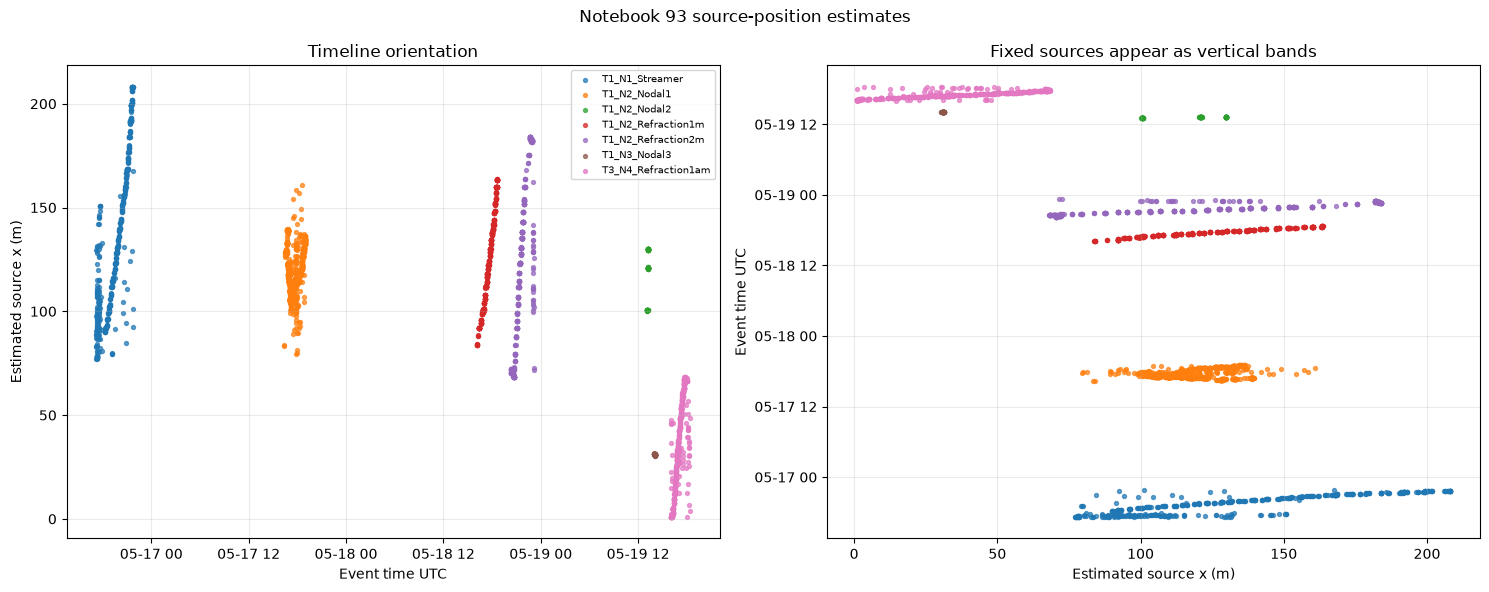

In [4]:
valid = estimates.dropna(subset=["event_time_dt", "estimated_source_x_m"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for label, sub in valid.groupby("timewindow_label", sort=True):
    color = TIMEWINDOW_COLORS.get(str(label), DEFAULT_SERIES_COLOR)
    axes[0].scatter(
        sub["event_time_dt"], sub["estimated_source_x_m"],
        s=8, alpha=0.7, color=color, label=label,
    )
    axes[1].scatter(
        sub["estimated_source_x_m"], sub["event_time_dt"],
        s=8, alpha=0.7, color=color, label=label,
    )

axes[0].set_xlabel("Event time UTC")
axes[0].set_ylabel("Estimated source x (m)")
axes[0].set_title("Timeline orientation")
axes[1].set_xlabel("Estimated source x (m)")
axes[1].set_ylabel("Event time UTC")
axes[1].set_title("Fixed sources appear as vertical bands")
for ax in axes:
    ax.grid(True, alpha=0.25)
axes[0].legend(fontsize=7, loc="best")
fig.suptitle("Notebook 93 source-position estimates")
fig.tight_layout()
save_figure(fig, "93b_source_position_vs_time.png")
plt.show()


## 4. Position distributions by survey window


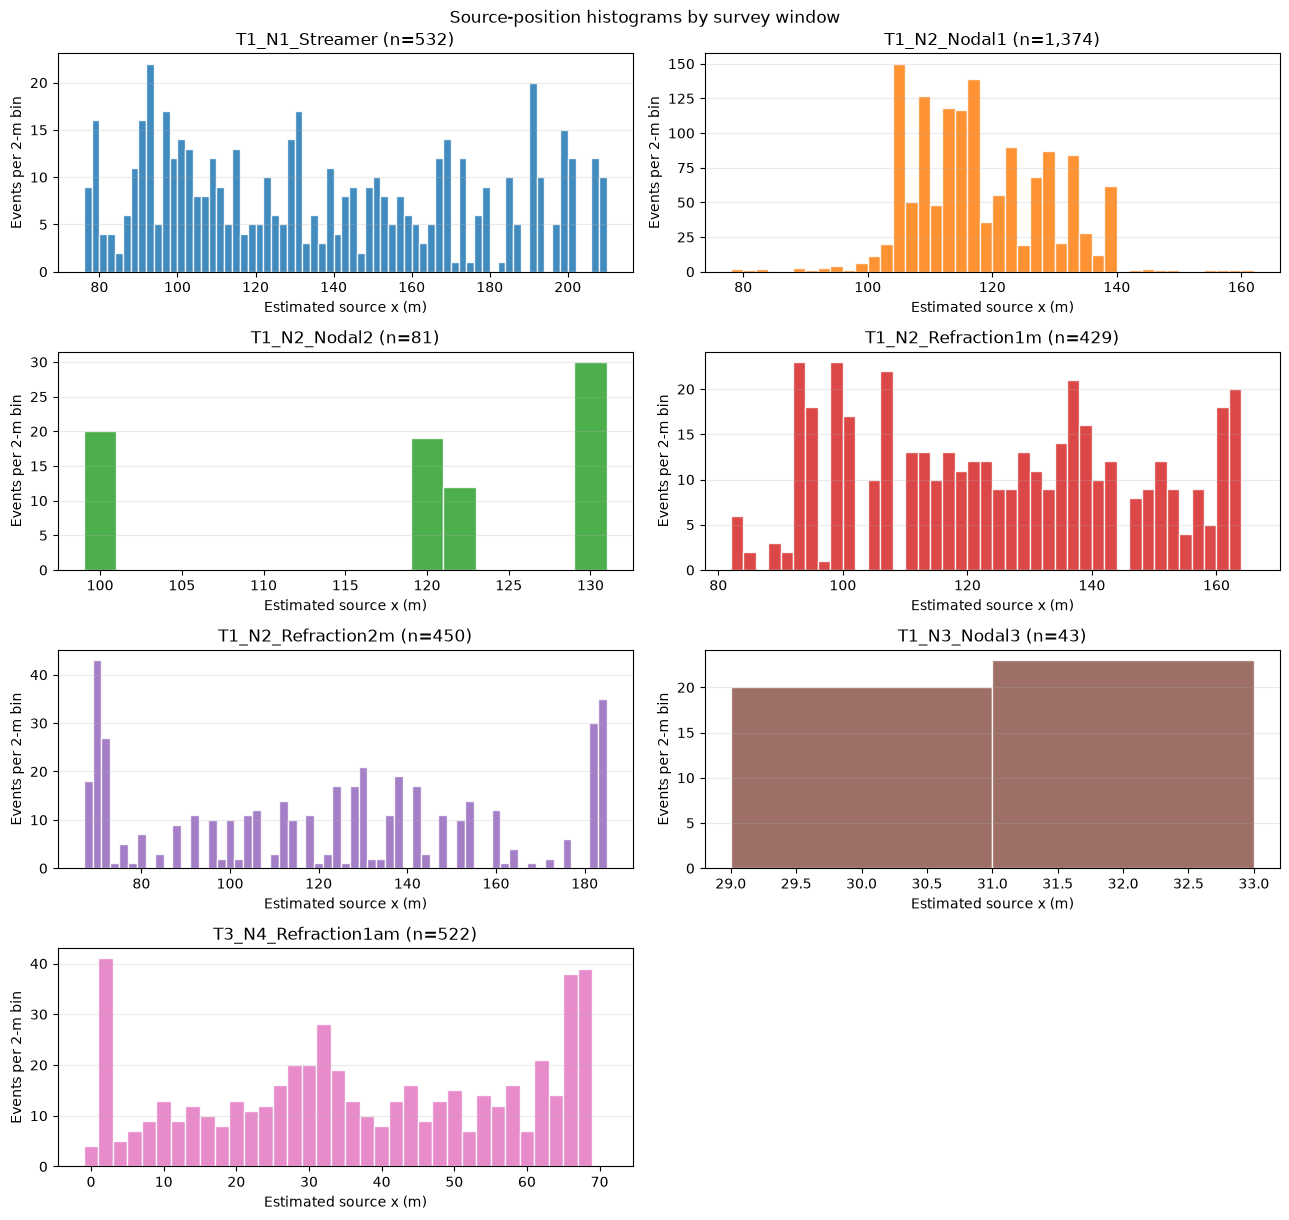

In [5]:
labels = sorted(valid["timewindow_label"].dropna().unique())
ncols = 2
nrows = math.ceil(len(labels) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.1 * nrows), squeeze=False)

for ax, label in zip(axes.flat, labels):
    sub = valid.loc[valid["timewindow_label"].eq(label), "estimated_source_x_m"]
    color = TIMEWINDOW_COLORS.get(str(label), DEFAULT_SERIES_COLOR)
    bins = np.arange(np.floor(sub.min()) - 1, np.ceil(sub.max()) + 3, 2.0)
    ax.hist(sub, bins=bins, color=color, alpha=0.85, edgecolor="white")
    ax.set_title(f"{label} (n={len(sub):,})")
    ax.set_xlabel("Estimated source x (m)")
    ax.set_ylabel("Events per 2-m bin")
    ax.grid(True, axis="y", alpha=0.25)
for ax in axes.flat[len(labels):]:
    ax.set_visible(False)
fig.suptitle("Source-position histograms by survey window")
fig.tight_layout()
save_figure(fig, "93b_source_position_histograms.png")
plt.show()


## 5. Per-window estimate and quality summaries


,timewindow_label,n_events,n_with_estimate,min_x_m,q25_x_m,median_x_m,q75_x_m,max_x_m,median_receivers_z,median_consensus_picks,median_energy_centroid_shift_m
0,T1_N1_Streamer,532,532,77.155,101.249,131.548,168.452,208.139,35.0,28.0,-0.072
1,T1_N2_Nodal1,1376,1376,79.624,109.640,116.355,126.630,160.876,33.0,20.0,0.098
2,T1_N2_Nodal2,81,81,100.282,120.493,121.013,129.783,129.903,34.0,18.0,-0.077
3,T1_N2_Refraction1m,431,431,83.822,106.084,124.197,141.827,163.527,34.0,31.0,0.047
4,T1_N2_Refraction2m,450,450,68.205,87.782,123.412,151.823,183.865,34.0,27.0,-0.031
5,T1_N3_Nodal3,43,43,30.438,30.875,31.016,31.205,31.541,34.0,18.0,3.016
6,T3_N4_Refraction1am,523,523,0.929,21.096,35.191,57.338,68.280,35.0,30.0,-0.223


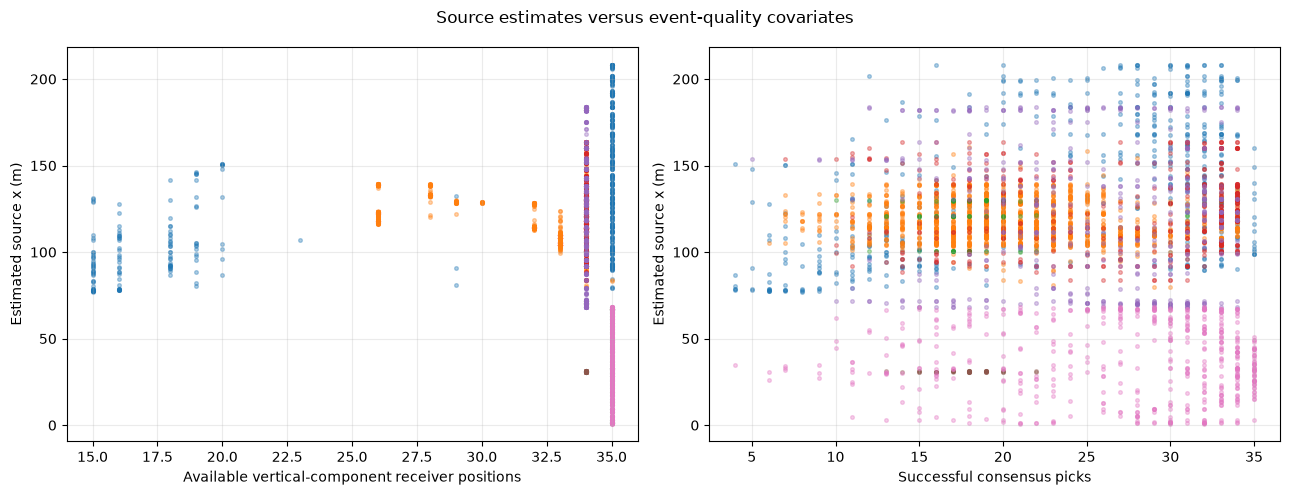

In [6]:
window_summary = (
    estimates.groupby("timewindow_label", dropna=False)
    .agg(
        n_events=("event_id", "count"),
        n_with_estimate=("estimated_source_x_m", "count"),
        min_x_m=("estimated_source_x_m", "min"),
        q25_x_m=("estimated_source_x_m", lambda s: s.quantile(0.25)),
        median_x_m=("estimated_source_x_m", "median"),
        q75_x_m=("estimated_source_x_m", lambda s: s.quantile(0.75)),
        max_x_m=("estimated_source_x_m", "max"),
        median_receivers_z=("n_receivers_z", "median"),
        median_consensus_picks=("n_consensus_picks", "median"),
        median_energy_centroid_shift_m=("estimate_minus_energy_x_m", "median"),
    )
    .reset_index()
)
display(window_summary.round(3))
save_table(window_summary, "93b_window_summary.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for label, sub in estimates.groupby("timewindow_label", sort=True):
    color = TIMEWINDOW_COLORS.get(str(label), DEFAULT_SERIES_COLOR)
    axes[0].scatter(sub["n_receivers_z"], sub["estimated_source_x_m"], s=7, alpha=0.35, color=color)
    axes[1].scatter(sub["n_consensus_picks"], sub["estimated_source_x_m"], s=7, alpha=0.35, color=color)
axes[0].set_xlabel("Available vertical-component receiver positions")
axes[1].set_xlabel("Successful consensus picks")
for ax in axes:
    ax.set_ylabel("Estimated source x (m)")
    ax.grid(True, alpha=0.25)
fig.suptitle("Source estimates versus event-quality covariates")
fig.tight_layout()
save_figure(fig, "93b_estimates_vs_quality.png")
plt.show()


## 6. Independent Geode validation using time only

Candidate pairs are formed when a nodal event has the corresponding acquisition label
and its event time falls within a Geode stack interval. Source position is not used.
If intervals overlap, the candidate with the closest final-trigger time is retained and
the ambiguity count is preserved. These results may contain false detections, but they
are independent of notebook 94's position threshold.


In [7]:
geode_valid = geode.dropna(
    subset=["nodal_timewindow_label", "stack_start_dt", "stack_end_dt", "source_x_m"]
).copy()
pair_columns = [
    "geode_event_id", "survey", "nodal_timewindow_label", "source_x_m",
    "stack_start_dt", "stack_end_dt", "geode_final_trigger_time_dt",
    "n_stack_shots", "file_no",
]
candidate_pairs = valid.merge(
    geode_valid[pair_columns],
    left_on="timewindow_label",
    right_on="nodal_timewindow_label",
    how="inner",
    suffixes=("_estimate", "_truth"),
)
candidate_pairs = candidate_pairs[
    candidate_pairs["event_time_dt"].between(
        candidate_pairs["stack_start_dt"], candidate_pairs["stack_end_dt"], inclusive="both"
    )
].copy()
candidate_pairs["time_from_final_s"] = (
    candidate_pairs["event_time_dt"] - candidate_pairs["geode_final_trigger_time_dt"]
).dt.total_seconds()
candidate_pairs["abs_time_from_final_s"] = candidate_pairs["time_from_final_s"].abs()
candidate_pairs["n_time_candidates"] = candidate_pairs.groupby("event_id")["geode_event_id"].transform("size")

time_matches = (
    candidate_pairs.sort_values(["event_id", "abs_time_from_final_s"])
    .drop_duplicates("event_id", keep="first")
    .copy()
)
time_matches["source_residual_m"] = (
    time_matches["estimated_source_x_m"] - time_matches["source_x_m"]
)
time_matches["abs_source_residual_m"] = time_matches["source_residual_m"].abs()

association_summary = pd.DataFrame(
    {
        "metric": [
            "time-only candidate pairs",
            "unique nodal events with a time-only match",
            "events with overlapping candidate intervals",
            "Geode stacks represented",
        ],
        "value": [
            len(candidate_pairs),
            time_matches["event_id"].nunique(),
            time_matches.loc[time_matches["n_time_candidates"].gt(1), "event_id"].nunique(),
            time_matches["geode_event_id"].nunique(),
        ],
    }
)
display(association_summary)
save_table(association_summary, "93b_time_only_association_summary.csv")
save_table(time_matches, "93b_time_only_geode_matches.csv")


,metric,value
0,time-only candidate pairs,966
1,unique nodal events with a time-only match,966
2,events with overlapping candidate intervals,0
3,Geode stacks represented,199


## 7. Accuracy against known Geode source positions


,survey,n_events,n_geode_stacks,bias_m,median_residual_m,mae_m,median_abs_error_m,rmse_m,robust_sigma_m,p90_abs_error_m
0,T1_1m_refraction,252,39,-0.056,-0.282,0.559,0.437,0.696,0.428,1.089
1,T1_2m_refraction,225,39,1.941,0.461,4.904,0.832,9.271,1.108,20.638
2,T1_streamer_masw,296,82,-0.208,-0.118,1.073,0.940,1.368,1.331,2.083
3,T3_1m_refraction,193,39,-1.166,-0.247,1.529,0.413,4.270,0.605,4.676


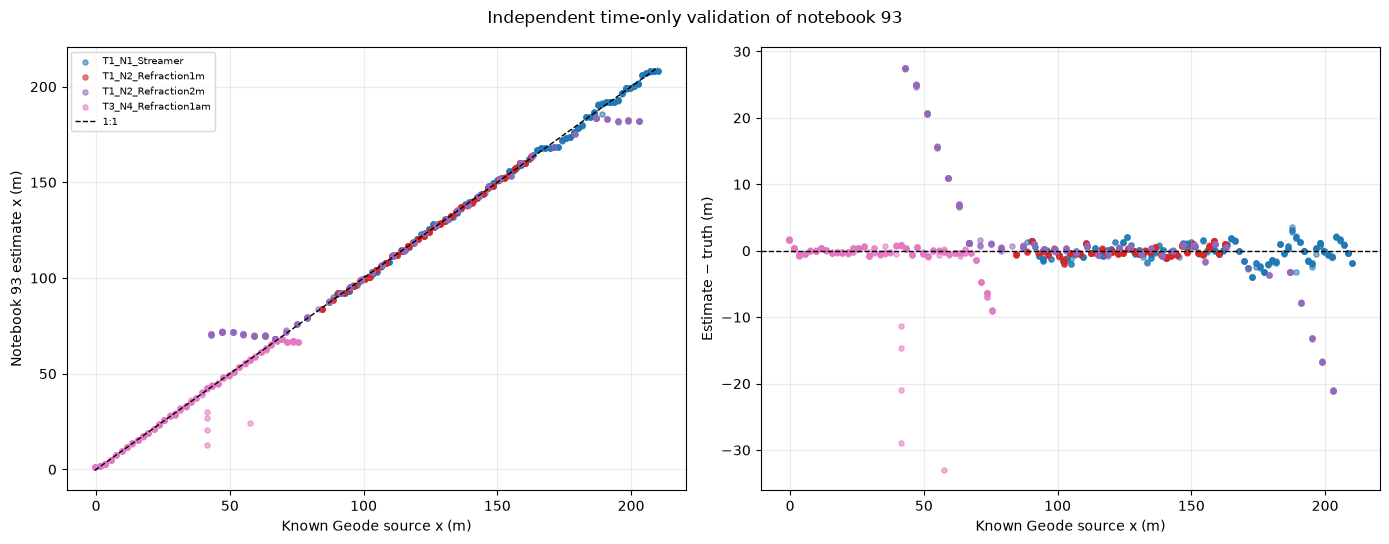

In [8]:
def rmse(series):
    x = pd.to_numeric(series, errors="coerce").dropna().to_numpy(float)
    return float(np.sqrt(np.mean(x ** 2))) if len(x) else np.nan

def robust_sigma(series):
    x = pd.to_numeric(series, errors="coerce").dropna()
    if x.empty:
        return np.nan
    med = x.median()
    return float(1.4826 * np.median(np.abs(x - med)))

validation_summary = (
    time_matches.groupby("survey", dropna=False)
    .agg(
        n_events=("event_id", "count"),
        n_geode_stacks=("geode_event_id", "nunique"),
        bias_m=("source_residual_m", "mean"),
        median_residual_m=("source_residual_m", "median"),
        mae_m=("abs_source_residual_m", "mean"),
        median_abs_error_m=("abs_source_residual_m", "median"),
        rmse_m=("source_residual_m", rmse),
        robust_sigma_m=("source_residual_m", robust_sigma),
        p90_abs_error_m=("abs_source_residual_m", lambda s: s.quantile(0.90)),
    )
    .reset_index()
)
display(validation_summary.round(3))
save_table(validation_summary, "93b_geode_validation_summary.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for label, sub in time_matches.groupby("timewindow_label", sort=True):
    color = TIMEWINDOW_COLORS.get(str(label), DEFAULT_SERIES_COLOR)
    axes[0].scatter(sub["source_x_m"], sub["estimated_source_x_m"], s=14, alpha=0.55, color=color, label=label)
    axes[1].scatter(sub["source_x_m"], sub["source_residual_m"], s=14, alpha=0.55, color=color, label=label)
finite = time_matches[["source_x_m", "estimated_source_x_m"]].to_numpy(float)
lo, hi = np.nanmin(finite), np.nanmax(finite)
axes[0].plot([lo, hi], [lo, hi], "k--", linewidth=1, label="1:1")
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_xlabel("Known Geode source x (m)")
axes[0].set_ylabel("Notebook 93 estimate x (m)")
axes[1].set_xlabel("Known Geode source x (m)")
axes[1].set_ylabel("Estimate − truth (m)")
for ax in axes:
    ax.grid(True, alpha=0.25)
axes[0].legend(fontsize=7, loc="best")
fig.suptitle("Independent time-only validation of notebook 93")
fig.tight_layout()
save_figure(fig, "93b_geode_validation.png")
plt.show()


## 8. Repeatability within known Geode stacks


n_events                                          \
                    count   mean    std  min  25%  50%  75%   max   
survey                                                              
T1_1m_refraction     39.0  6.462  1.714  2.0  6.0  6.0  7.0  10.0   
T1_2m_refraction     36.0  6.167  1.920  3.0  5.0  6.0  7.0  13.0   
T1_streamer_masw     80.0  3.675  1.199  2.0  3.0  3.0  4.0   8.0   
T3_1m_refraction     39.0  4.949  1.555  3.0  4.0  5.0  5.0  10.0   

                 within_stack_std_m         ...                 \
                              count   mean  ...    75%     max   
survey                                      ...                  
T1_1m_refraction               39.0  0.063  ...  0.079   0.346   
T1_2m_refraction               36.0  0.087  ...  0.133   0.478   
T1_streamer_masw               80.0  0.117  ...  0.115   2.353   
T3_1m_refraction               39.0  0.764  ...  0.253  13.453   

                 median_abs_error_m                                            \
                              count   mean    std    min    25%    50%    75%   
survey                                                                          
T1_1m_refraction               39.0  0.540  0.405  0.037  0.276  0.438  0.672   
T1_2m_refraction               36.0  5.197  7.996  0.044  0.451  0.842  7.101   
T1_streamer_masw               80.0  1.029  0.817  0.015  0.421  0.885  1.497   
T3_1m_refraction               39.0  0.928  1.782  0.026  0.278  0.391  0.636   

                          
                     max  
survey                    
T1_1m_refraction   1.721  
T1_2m_refraction  27.515  
T1_streamer_masw   3.971  
T3_1m_refraction   8.981  

[4 rows x 24 columns]

,geode_event_id,survey,n_events,source_x_truth_m,mean_estimated_x_m,median_estimated_x_m,mean_residual_m,within_stack_std_m,within_stack_range_m,median_abs_error_m
189,GEODE_T3_1M_REFRACTION_F4030,T3_1m_refraction,6,57.5,51.905,57.276,-5.595,13.453,33.327,0.233
181,GEODE_T3_1M_REFRACTION_F4022,T3_1m_refraction,10,41.5,34.393,42.234,-7.107,11.146,29.799,0.846
145,GEODE_T1_STREAMER_MASW_F1069,T1_streamer_masw,5,189.0,189.980,190.952,0.980,2.353,5.478,2.005
180,GEODE_T3_1M_REFRACTION_F4021,T3_1m_refraction,4,39.5,39.919,40.181,0.419,0.617,1.318,0.681
178,GEODE_T3_1M_REFRACTION_F4019,T3_1m_refraction,4,35.5,35.402,35.174,-0.098,0.574,1.243,0.442
46,GEODE_T1_2M_REFRACTION_F3054,T1_2m_refraction,3,71.0,72.051,71.819,1.051,0.478,0.867,0.819
89,GEODE_T1_STREAMER_MASW_F1013,T1_streamer_masw,3,105.0,103.204,102.949,-1.796,0.441,0.763,2.051
150,GEODE_T1_STREAMER_MASW_F1074,T1_streamer_masw,5,196.5,196.725,196.923,0.225,0.404,0.934,0.424
176,GEODE_T3_1M_REFRACTION_F4017,T3_1m_refraction,4,31.5,31.540,31.562,0.040,0.404,0.781,0.368
119,GEODE_T1_STREAMER_MASW_F1043,T1_streamer_masw,3,150.0,151.075,151.300,1.075,0.402,0.703,1.300


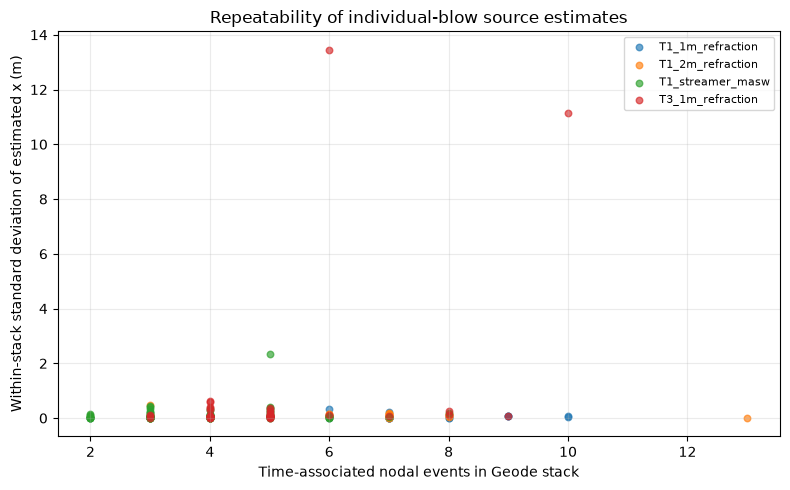

In [9]:
group_stats = (
    time_matches.groupby(["geode_event_id", "survey"], dropna=False)
    .agg(
        n_events=("event_id", "count"),
        source_x_truth_m=("source_x_m", "first"),
        mean_estimated_x_m=("estimated_source_x_m", "mean"),
        median_estimated_x_m=("estimated_source_x_m", "median"),
        mean_residual_m=("source_residual_m", "mean"),
        within_stack_std_m=("estimated_source_x_m", "std"),
        within_stack_range_m=("estimated_source_x_m", lambda s: s.max() - s.min()),
        median_abs_error_m=("abs_source_residual_m", "median"),
    )
    .reset_index()
)
repeatable = group_stats[group_stats["n_events"].ge(2)].copy()
display(repeatable.groupby("survey")[["n_events", "within_stack_std_m", "median_abs_error_m"]].describe().round(3))
display(repeatable.sort_values("within_stack_std_m", ascending=False).head(20).round(3))
save_table(group_stats, "93b_geode_within_stack_repeatability.csv")

fig, ax = plt.subplots(figsize=(8, 5))
for survey, sub in repeatable.groupby("survey", sort=True):
    ax.scatter(sub["n_events"], sub["within_stack_std_m"], s=22, alpha=0.65, label=survey)
ax.set_xlabel("Time-associated nodal events in Geode stack")
ax.set_ylabel("Within-stack standard deviation of estimated x (m)")
ax.set_title("Repeatability of individual-blow source estimates")
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8)
fig.tight_layout()
save_figure(fig, "93b_within_stack_repeatability.png")
plt.show()


## 9. Nodal-only position–time structure

This section remains exploratory. Consecutive-event time and position differences are
diagnostics, not group assignments. A later `94b_*` notebook should only define groups
if compact temporal sequences and stable source estimates are evident here.


,timewindow_label,n_events,duration_minutes,median_dt_s,p90_dt_s,median_abs_dx_m,p90_abs_dx_m
0,T1_N2_Nodal1,1374,160.421,2.524,13.144,0.159,3.554
1,T1_N2_Nodal2,81,7.780,2.358,3.526,0.084,0.303
2,T1_N3_Nodal3,43,3.002,2.374,8.025,0.217,0.427


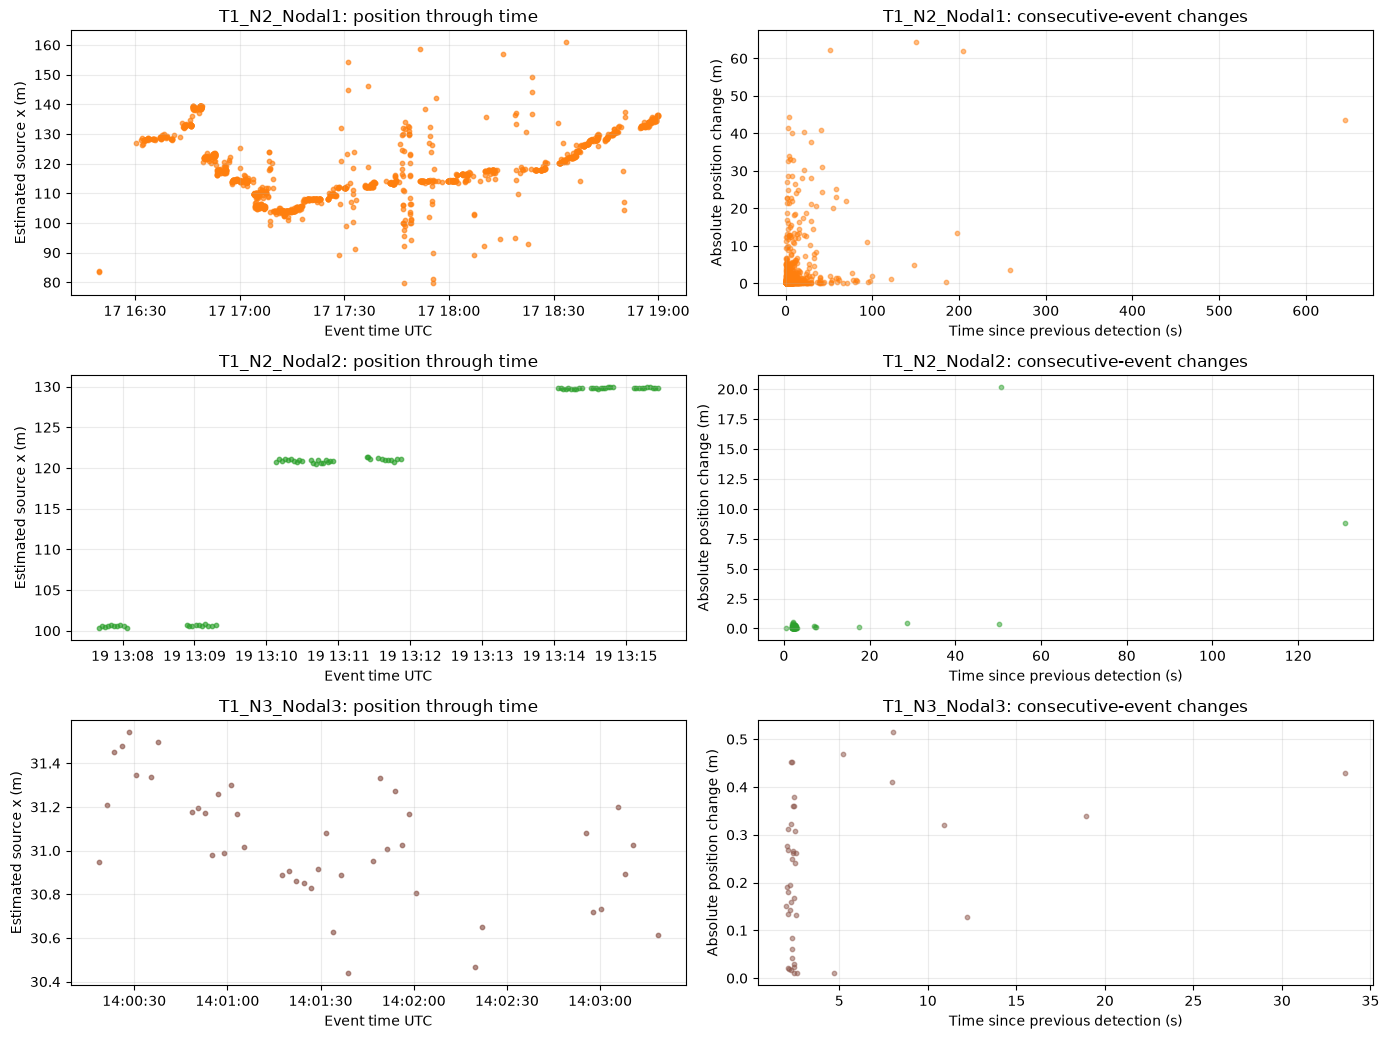

In [10]:
nodal_only = valid[valid["timewindow_label"].isin(NODAL_ONLY_LABELS)].copy()
nodal_only = nodal_only.sort_values(["timewindow_label", "event_time_dt"])
nodal_only["dt_previous_s"] = nodal_only.groupby("timewindow_label")["event_time_dt"].diff().dt.total_seconds()
nodal_only["dx_previous_m"] = nodal_only.groupby("timewindow_label")["estimated_source_x_m"].diff()
nodal_only["abs_dx_previous_m"] = nodal_only["dx_previous_m"].abs()

sequence_summary = (
    nodal_only.groupby("timewindow_label")
    .agg(
        n_events=("event_id", "count"),
        duration_minutes=("event_time_dt", lambda s: (s.max() - s.min()).total_seconds() / 60),
        median_dt_s=("dt_previous_s", "median"),
        p90_dt_s=("dt_previous_s", lambda s: s.quantile(0.90)),
        median_abs_dx_m=("abs_dx_previous_m", "median"),
        p90_abs_dx_m=("abs_dx_previous_m", lambda s: s.quantile(0.90)),
    )
    .reset_index()
)
display(sequence_summary.round(3))
save_table(sequence_summary, "93b_nodal_only_sequence_summary.csv")
save_table(nodal_only, "93b_nodal_only_event_diagnostics.csv")

fig, axes = plt.subplots(len(NODAL_ONLY_LABELS), 2, figsize=(14, 3.5 * len(NODAL_ONLY_LABELS)), squeeze=False)
for row, label in enumerate(NODAL_ONLY_LABELS):
    sub = nodal_only[nodal_only["timewindow_label"].eq(label)]
    color = TIMEWINDOW_COLORS[label]
    axes[row, 0].scatter(sub["event_time_dt"], sub["estimated_source_x_m"], s=10, alpha=0.65, color=color)
    axes[row, 0].set_title(f"{label}: position through time")
    axes[row, 0].set_xlabel("Event time UTC")
    axes[row, 0].set_ylabel("Estimated source x (m)")
    axes[row, 1].scatter(sub["dt_previous_s"], sub["abs_dx_previous_m"], s=10, alpha=0.5, color=color)
    axes[row, 1].set_title(f"{label}: consecutive-event changes")
    axes[row, 1].set_xlabel("Time since previous detection (s)")
    axes[row, 1].set_ylabel("Absolute position change (m)")
    for ax in axes[row]:
        ax.grid(True, alpha=0.25)
fig.tight_layout()
save_figure(fig, "93b_nodal_only_position_time_diagnostics.png")
plt.show()


## 10. Representative waveform overlays

Three time-only Geode groups are selected from groups with at least three members:
the smallest, median-like, and largest within-stack source-estimate scatter. For each
event, the vertical trace nearest the known source coordinate is normalized and
overlaid. These plots test repeatability qualitatively; they do not align or stack the
waveforms.


,geode_event_id,survey,n_events,source_x_truth_m,mean_estimated_x_m,median_estimated_x_m,mean_residual_m,within_stack_std_m,within_stack_range_m,median_abs_error_m
141,GEODE_T1_STREAMER_MASW_F1065,T1_streamer_masw,4,183.0,184.023,184.023,1.023,0.002,0.004,1.023
25,GEODE_T1_1M_REFRACTION_F3033,T1_1m_refraction,7,136.5,136.990,136.995,0.490,0.058,0.160,0.495
189,GEODE_T3_1M_REFRACTION_F4030,T3_1m_refraction,6,57.5,51.905,57.276,-5.595,13.453,33.327,0.233


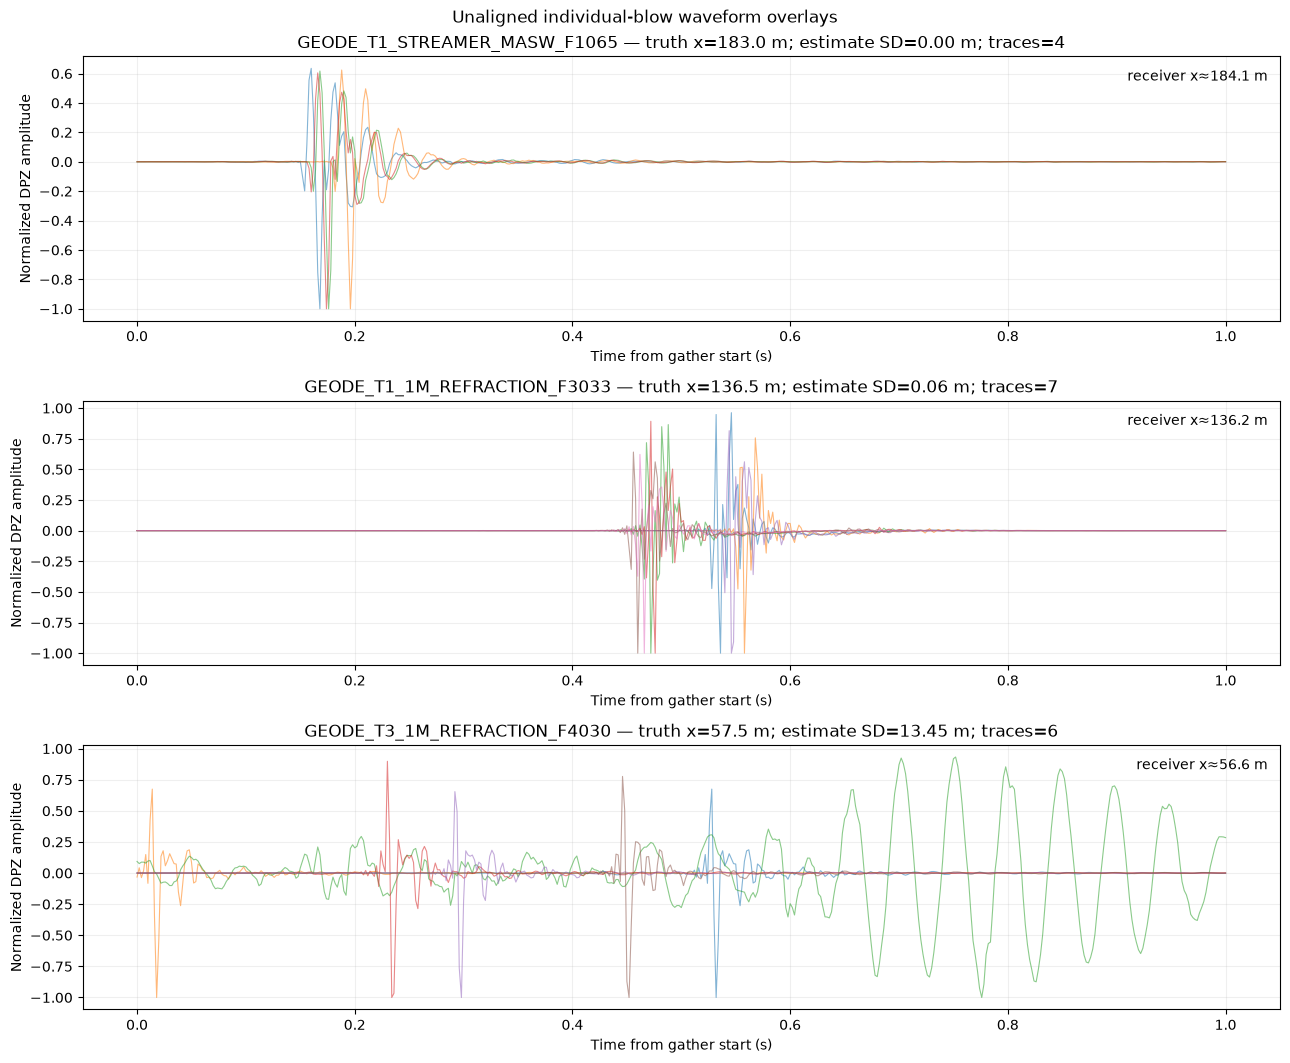

In [11]:
waveform_examples = pd.DataFrame()

if RUN_WAVEFORM_EXAMPLES:
    from obspy import read

    eligible = repeatable[repeatable["n_events"].ge(3) & repeatable["within_stack_std_m"].notna()].copy()
    if eligible.empty:
        print("No Geode groups with at least three time-associated events were available.")
    else:
        eligible = eligible.sort_values("within_stack_std_m")
        target_indices = sorted(set([0, len(eligible) // 2, len(eligible) - 1]))
        waveform_examples = eligible.iloc[target_indices].copy()
        display(waveform_examples.round(3))
        save_table(waveform_examples, "93b_waveform_example_groups.csv")

        def reference_trace(event_id, mseed_path, target_x_m):
            with sqlite3.connect(DB_URI, uri=True) as conn:
                geom = pd.read_sql_query(
                    """
                    SELECT station, channel, receiver_x_m
                    FROM trace_index
                    WHERE instrument_system = 'nodal'
                      AND event_id = ?
                      AND (component = 'Z' OR channel LIKE '%Z')
                    """,
                    conn,
                    params=[str(event_id)],
                )
            geom["receiver_x_m"] = pd.to_numeric(geom["receiver_x_m"], errors="coerce")
            geom = geom.dropna(subset=["receiver_x_m"]).copy()
            if geom.empty:
                return None, np.nan
            geom["distance_to_target_m"] = (geom["receiver_x_m"] - float(target_x_m)).abs()
            chosen = geom.sort_values("distance_to_target_m").iloc[0]
            path = Path(str(mseed_path))
            # The gather archive was renamed after these paths were cataloged.
            # Resolve the current root without modifying the database provenance.
            if not path.is_file() and "nodal_fullnode_shotgathers_v4" in path.parts:
                old_root_index = path.parts.index("nodal_fullnode_shotgathers_v4")
                relative_path = Path(*path.parts[old_root_index + 1:])
                relocated = PROJECT_ROOT / "nodal_unstacked_shotgathers" / relative_path
                if relocated.is_file():
                    path = relocated
            if not path.is_file():
                return None, float(chosen["receiver_x_m"])
            try:
                st = read(str(path))
            except (FileNotFoundError, OSError):
                return None, float(chosen["receiver_x_m"])
            selected = st.select(station=str(chosen["station"]), channel=str(chosen["channel"]))
            if not selected:
                selected = st.select(station=str(chosen["station"]), channel="*Z")
            return (selected[0].copy(), float(chosen["receiver_x_m"])) if selected else (None, np.nan)

        fig, axes = plt.subplots(len(waveform_examples), 1, figsize=(13, 3.6 * len(waveform_examples)), squeeze=False)
        for ax, (_, group) in zip(axes.flat, waveform_examples.iterrows()):
            members = time_matches[time_matches["geode_event_id"].eq(group["geode_event_id"])].copy()
            members = members.sort_values("event_time_dt").head(MAX_WAVEFORMS_PER_GROUP)
            plotted = 0
            receiver_used = []
            for _, event in members.iterrows():
                tr, receiver_x = reference_trace(event["event_id"], event["mseed_path"], group["source_x_truth_m"])
                if tr is None or tr.stats.npts < 2:
                    continue
                y = np.asarray(tr.data, dtype=float)
                y = y - np.nanmedian(y)
                scale = np.nanmax(np.abs(y))
                if not np.isfinite(scale) or scale == 0:
                    continue
                t = np.arange(tr.stats.npts) / float(tr.stats.sampling_rate)
                ax.plot(t, y / scale, alpha=0.55, linewidth=0.8)
                receiver_used.append(receiver_x)
                plotted += 1
            ax.set_title(
                f"{group['geode_event_id']} — truth x={group['source_x_truth_m']:.1f} m; "
                f"estimate SD={group['within_stack_std_m']:.2f} m; traces={plotted}"
            )
            ax.set_xlabel("Time from gather start (s)")
            ax.set_ylabel("Normalized DPZ amplitude")
            ax.grid(True, alpha=0.2)
            if receiver_used:
                ax.text(0.99, 0.95, f"receiver x≈{np.median(receiver_used):.1f} m", transform=ax.transAxes, ha="right", va="top")
        fig.suptitle("Unaligned individual-blow waveform overlays")
        fig.tight_layout()
        save_figure(fig, "93b_waveform_overlays.png")
        plt.show()
else:
    print("Waveform examples disabled. Set RUN_WAVEFORM_EXAMPLES = True to generate them.")


## 11. Decision checkpoint before `94b_*`

Do not choose grouping tolerances solely from the overall position histograms. Use the
independent Geode residuals and within-stack scatter to establish the accuracy and
repeatability of the energy proxy. Then inspect each nodal-only window separately:

- Clear compact time sequences with position spread comparable to known Geode stacks
  support automated candidate grouping.
- Systematic Geode residuals support applying a documented calibration before grouping.
- Broad or multimodal within-stack errors mean position alone is insufficient; temporal
  structure and waveform similarity must carry more weight.
- `T1_N2_Nodal1`, with 1,376 detections, should be treated especially cautiously until
  false detections and revisits to the same position are distinguished.

This notebook intentionally creates no authoritative group IDs. Those belong in a later
`94b_group_nodal_only_events_into_candidate_shots.ipynb` only after this review.
